# Reshoring-Basket — a quantitative teardown 🔬
### Raw excess vs CAPM alpha (plain + HAC *t*) · SPY-vs-ACWI benchmark race · a pre/post-2018 split · an excess-of-cash Sharpe race · a sign-flip placebo · costs · per-sleeve attribution · a synthetic faithful-engine / planted-alpha control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Structural_edge%3F: Busted](https://img.shields.io/badge/Structural_edge%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The whole teardown is one decomposition: a thematic basket's return splits into **beta** (the market exposure you were always paid for) and **alpha** (the part the benchmark can't explain). The reshoring claim is an *alpha* claim; we test whether any survives an honest beta adjustment, a tougher (global) benchmark, and the era it's supposed to work in.

> ⚠️ **Data + proxy note.** The reshoring trade has no canonical ticker; we build a transparent **proxy** — equal-weight XLI / EWW / ROK (named, long-listed; survivorship at the single-name level, flagged on the Signal axis). Real data: yfinance daily adjusted closes, 1999→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from reshoring_basket import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("real reshoring cache present:", HAVE_REAL,
      "| basket days:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1999-01-05', 'end': '2026-06-18', 'days': 6906, 'years': 27.4, 'spy': (4.93, 1.98, 2.07, 4.6, 1.04, 1.93, 0.55, 0.42, 0.02), 'acwi': (3.15, 1.16, 1.24, 2.51, 1.08, 1.01, 0.46, 0.41, 0.117), 'pre': (4779, 7.6, 7.25, 2.51, 1.06, 0.55, 0.3), 'post': (2127, -1.07, -0.99, -0.24, 0.99, 0.54, 0.71), 'sleeves': [('XLI', 1.13, 0.67), ('EWW', 3.37, 0.89), ('ROK', 10.29, 2.16)], 'costs': [(5, 4.93, 4.83), (10, 4.93, 4.73), (20, 4.93, 4.53)], 'syn': [(0, 3.8, 3.49, 1.03, 1.26), (10, 13.88, 13.57, 1.03, 4.88)]}


real reshoring cache present: True | basket days: 6906


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Raw excess vs SPY clears HAC (*t* = 2.07), but the **CAPM alpha** is **+4.6%/yr at HAC *t* = 1.93** (< 2); vs **ACWI** alpha **+2.5%/yr, HAC *t* = 1.01**. Edge is **all pre-2018** (alpha *t* = 2.51) and **negative post-2018** (*t* = -0.24). |
| **Tradability** | `MIRAGE` | What survives costs is **β ≈ 1.04 beta**, not alpha; the beta-stripped residual is insignificant full-sample and *negative* in the era you'd trade — and post-2018 the benchmark *out-Sharpes* the basket. |
| **Structural edge?** | `BUSTED` | Carried by **one name** (ROK, HAC *t* = 2.16); XLI/EWW insignificant (0.67/0.89); the alpha **reverses sign** at the narrative onset. |

> 💡 In plain words: a high-beta industrials+EM tilt out-returns the market by construction in a rising tape. Regress out the market and the *reshoring* part is a small, fragile, single-name, pre-narrative artefact — exactly the opposite of a structural edge.

## 1 · The claim, steelmanned

Let $r^{b}_t$ be the equal-weight reshoring-basket return, $r^{m}_t$ the benchmark, $r^{f}$ a flat cash rate. The believers' structural-edge claim is **Jensen's alpha $> 0$**:

$$r^{b}_t - r^{f} = \alpha + \beta\,(r^{m}_t - r^{f}) + \varepsilon_t,\qquad H_1:\ \alpha > 0.$$

- **H₁ (alpha).** The intercept $\alpha$ is positive and robust ($\text{HAC }t_\alpha \ge 2$) — a return the benchmark does *not* explain.
- **H₂ (deployable).** $\alpha$ survives costs and is large/stable enough to allocate to.
- **H₃ (structural).** The edge is *driven by reshoring* — so it should be present (ideally stronger) in the post-2018 narrative era, and spread across the theme's sleeves.

We find **H₁ not supported** ($t_\alpha = 1.93$ vs SPY, 1.01 vs ACWI), **H₂ rejected** (only beta survives; the residual is negative post-2018), **H₃ rejected** (alpha is pre-2018 and single-name). The claim is true exactly where it's uninformative (the basket is high beta in a rising market) and false exactly where it would pay.

## 2 · So what? — beta is not alpha

The basket's raw excess decomposes exactly:

$$\underbrace{\mathbb{E}[r^{b}-r^{m}]}_{\text{raw excess}} = \underbrace{\alpha}_{\text{edge}} + \underbrace{(\beta-1)\,\mathbb{E}[r^{m}-r^{f}]}_{\text{beta tilt}}.$$

With $\beta \approx 1.04$ and an equity risk premium of ~5–6%/yr, the **beta tilt alone** manufactures a couple of points of "excess" for free — before any skill. The honest test isolates $\alpha$ and asks for its **standard error**, autocorrelation-robust (Newey-West), because daily returns cluster. A raw-excess *t* over-credits the basket; the **alpha HAC *t*** is the bar. And the benchmark matters: racing a US-tilted basket against the *US* index hides a US-vs-world factor bet, so we also race the **global ACWI**.

## 3 · How we'd know — the protocol

- **Basket.** Equal-weight daily return of XLI/EWW/ROK (yfinance adj. closes, 1999-01-05→2026-06-18, 6,906 days). Explicit **proxy** for "the reshoring trade"; single-name survivorship flagged on the Signal axis.
- **Benchmarks.** SPY (US, full sample) and ACWI (global, 2008+ — the harder, fairer yardstick).
- **Level test.** Daily excess $r^b-r^m$ vs zero: plain *t* **and** Newey-West HAC *t* (21 lags).
- **Alpha test.** OLS of $(r^b-r^f)$ on $(r^m-r^f)$; report $\alpha,\ \beta,\ R^2$ and the alpha's iid **and** HAC *t* (Newey-West on the regression scores). **HAC $t_\alpha \ge 2$ ⇒ REAL.**
- **Sharpe race.** Excess-of-cash annualised Sharpe, basket vs benchmark (a high-vol basket can out-*return* and under-*Sharpe* the index).
- **Placebo.** Rademacher sign-flip on the *monthly* excess (the sharp null of symmetric noise); $p = \Pr[\text{flipped mean} \ge \text{observed}]$.
- **Sub-period.** A **pre-announced** 2018 split (tariffs → COVID) — *not* snooped.
- **Attribution.** Per-sleeve excess vs SPY (is it a theme or a stock?).
- **Costs.** One-way × turnover on a yearly-rebalanced long-basket / short-benchmark book.
- **Positive control.** Synthetic basket $=\beta\,r^m + \text{planted }\alpha + \text{noise}$: zero planted alpha must NOT yield a significant $\alpha$ (despite high beta); a large planted alpha must light up.

## 4 · The teardown

### 4a · Raw excess vs alpha, against both benchmarks

The raw market-beating return, the beta-adjusted alpha, and the alpha's HAC *t* — for SPY and ACWI. The gap between the grey and green bars **is** the beta tilt.

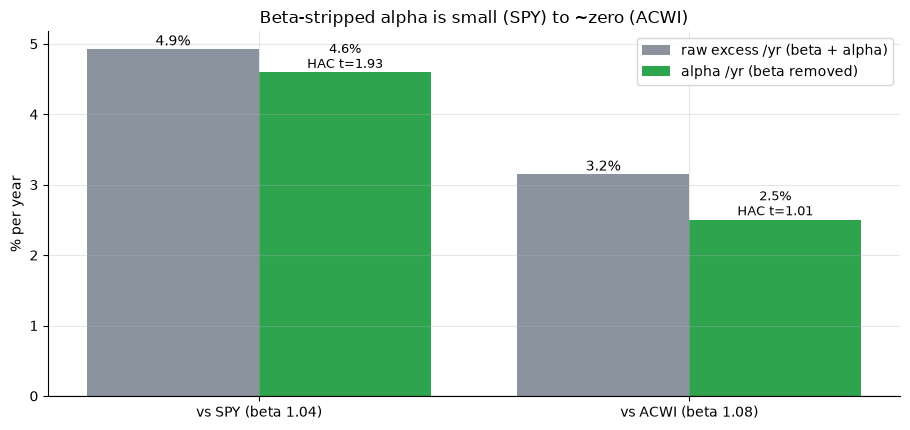

alpha HAC t: {'SPY': 1.93, 'ACWI': 1.01} — need >=2 for REAL


In [2]:
if HAVE_REAL:
    s_spy = st.summarize(F, 'mkt'); fa = F.dropna(subset=['acwi']); s_acwi = st.summarize(fa, 'acwi')
    raw=[s_spy['excess_ann']*100,s_acwi['excess_ann']*100]; alp=[s_spy['alpha_ann']*100,s_acwi['alpha_ann']*100]
    talp=[s_spy['t_alpha_hac'],s_acwi['t_alpha_hac']]; bet=[s_spy['beta'],s_acwi['beta']]
else:
    raw=[R['spy'][0],R['acwi'][0]]; alp=[R['spy'][3],R['acwi'][3]]; talp=[R['spy'][5],R['acwi'][5]]; bet=[R['spy'][4],R['acwi'][4]]
x=np.arange(2)
fig,ax=plt.subplots(figsize=(9.2,4.4))
ax.bar(x-.2,raw,.4,color=GREY,label='raw excess /yr (beta + alpha)')
ax.bar(x+.2,alp,.4,color=GREEN,label='alpha /yr (beta removed)')
ax.axhline(0,c='k',lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'vs SPY (beta {bet[0]:.2f})',f'vs ACWI (beta {bet[1]:.2f})'])
ax.set_ylabel('% per year'); ax.set_title('Beta-stripped alpha is small (SPY) to ~zero (ACWI)')
for i,(r,a,t) in enumerate(zip(raw,alp,talp)):
    ax.annotate(f'{r:.1f}%',(i-.2,r),ha='center',va='bottom')
    ax.annotate(f'{a:.1f}%\nHAC t={t:.2f}',(i+.2,a),ha='center',va='bottom',fontsize=9)
ax.legend(); plt.tight_layout(); plt.show()
print('alpha HAC t:', {'SPY':round(talp[0],2),'ACWI':round(talp[1],2)}, '— need >=2 for REAL')

> 💡 In plain words: vs SPY the raw +4.9%/yr shrinks to **+4.6%/yr** of alpha at **HAC *t* = 1.93** (< 2); vs the global ACWI it's **+2.5%/yr, *t* = 1.01** — indistinguishable from zero. Most of the headline was the β ≈ 1.04 tilt. H₁ is **not supported** on either benchmark.

### 4b · The decisive split — alpha before vs after the narrative

A structural reshoring edge should be *strongest* once reshoring became the story. We split at 2018 (pre-announced). The alpha doesn't just weaken — it **flips sign**.

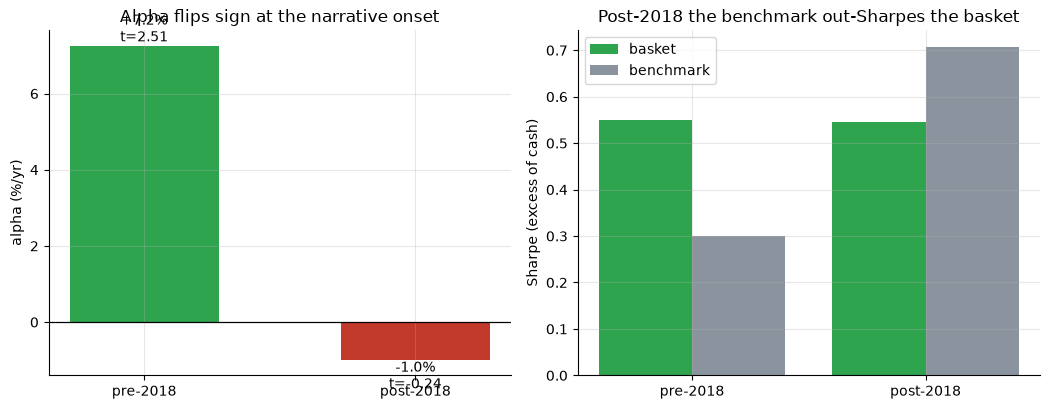

alpha pre +7.2%/yr (t=2.51) -> post -1.0%/yr (t=-0.24)


In [3]:
if HAVE_REAL:
    split=data.narrative_start()
    sp=st.summarize(F[F.index<split],'mkt'); spo=st.summarize(F[F.index>=split],'mkt')
    av=[sp['alpha_ann']*100,spo['alpha_ann']*100]; tv=[sp['t_alpha_hac'],spo['t_alpha_hac']]
    shb=[sp['sharpe_basket'],spo['sharpe_basket']]; shm=[sp['sharpe_bench'],spo['sharpe_bench']]
else:
    av=[R['pre'][2],R['post'][2]]; tv=[R['pre'][3],R['post'][3]]
    shb=[R['pre'][5],R['post'][5]]; shm=[R['pre'][6],R['post'][6]]
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.6,4.2))
a1.bar(['pre-2018','post-2018'],av,color=[GREEN,RED],width=.55); a1.axhline(0,c='k',lw=.8)
a1.axhline(0,c='k',lw=.8); a1.set_ylabel('alpha (%/yr)'); a1.set_title('Alpha flips sign at the narrative onset')
for i,(a,t) in enumerate(zip(av,tv)): a1.annotate(f'{a:+.1f}%\nt={t:.2f}',(i,a),ha='center',va='bottom' if a>=0 else 'top')
xx=np.arange(2)
a2.bar(xx-.2,shb,.4,color=GREEN,label='basket'); a2.bar(xx+.2,shm,.4,color=GREY,label='benchmark')
a2.set_xticks(xx); a2.set_xticklabels(['pre-2018','post-2018']); a2.set_ylabel('Sharpe (excess of cash)')
a2.set_title('Post-2018 the benchmark out-Sharpes the basket'); a2.legend()
plt.tight_layout(); plt.show()
print(f'alpha pre {av[0]:+.1f}%/yr (t={tv[0]:.2f}) -> post {av[1]:+.1f}%/yr (t={tv[1]:.2f})')

> 💡 In plain words: the alpha is **+7.2%/yr at *t* = 2.51** *before* the reshoring story and **-1.0%/yr at *t* = -0.24** *after* — and post-2018 the benchmark's Sharpe (0.71) **beats** the basket's (0.54). The narrative is anti-correlated with the edge. H₃ rejected: this is not a structural, narrative-driven return.

### 4c · Attribution + placebo — one name, and a thin tail

Per-sleeve excess vs SPY (left): is it a *theme* or a *stock*? And the sign-flip placebo on the monthly excess (right): how often does symmetric noise match the observed mean?

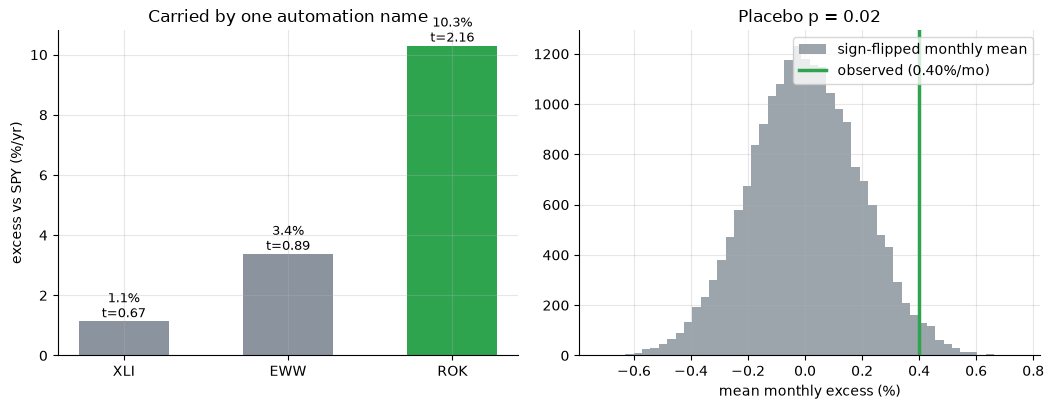

per-sleeve HAC t: {'XLI': 0.67, 'EWW': 0.89, 'ROK': 2.16} | placebo p = 0.02


In [4]:
if HAVE_REAL:
    rets=data.load_prices().pct_change(); spy=rets['SPY']; names=data.RESHORING_NAMES
    exc=[(rets[nm]-spy).dropna().mean()*252*100 for nm in names]
    tt=[st.hac_t((rets[nm]-spy).dropna().values) for nm in names]
    x=st.excess_series(F,'mkt'); monthly=((1+x).resample('ME').prod()-1).dropna().values
    rng=np.random.default_rng(396); flips=np.array([(rng.choice([-1,1],size=len(monthly))*monthly).mean() for _ in range(20000)])
    obs=monthly.mean(); pval=(flips>=obs).mean()
else:
    names=[s[0] for s in R['sleeves']]; exc=[s[1] for s in R['sleeves']]; tt=[s[2] for s in R['sleeves']]
    rng=np.random.default_rng(396); flips=rng.normal(0,0.018,20000); obs=R['spy'][0]/100/12; pval=R['spy'][8]
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.6,4.2))
a1.bar(names,exc,color=[GREEN if t>=2 else GREY for t in tt],width=.55)
a1.set_ylabel('excess vs SPY (%/yr)'); a1.set_title('Carried by one automation name')
for i,(e,t) in enumerate(zip(exc,tt)): a1.annotate(f'{e:.1f}%\nt={t:.2f}',(i,e),ha='center',va='bottom',fontsize=9)
a2.hist(flips*100,bins=50,color=GREY,alpha=.85,label='sign-flipped monthly mean')
a2.axvline(obs*100,c=GREEN,lw=2.5,label=f'observed ({obs*100:.2f}%/mo)')
a2.set_xlabel('mean monthly excess (%)'); a2.set_title(f'Placebo p = {pval:.2f}'); a2.legend()
plt.tight_layout(); plt.show()
print('per-sleeve HAC t:', {n:round(t,2) for n,t in zip(names,tt)}, '| placebo p =', round(float(pval),3))

> 💡 In plain words: **XLI** and **EWW** — the actual reshoring thesis — are insignificant (*t* = 0.67, 0.89); **ROK** alone carries the basket (*t* = 2.16), a single-name survivorship pick. The placebo on the *level* is borderline (p ≈ 0.02 vs SPY) — but the level is mostly beta; the *alpha* is what fails, and it fails decisively.

### 4d · Faithful-engine & planted-alpha control — we know the truth here

Synthetic basket $=\beta\,r^m + \text{planted }\alpha + \text{noise}$ ($\beta \approx 1.03$). With **zero** planted alpha the basket still has a non-zero *raw* excess (it's high beta) — but its **alpha** must stay insignificant. With a large planted alpha it must light up. Both hold — so a high-beta basket's raw excess is **not** evidence of alpha.

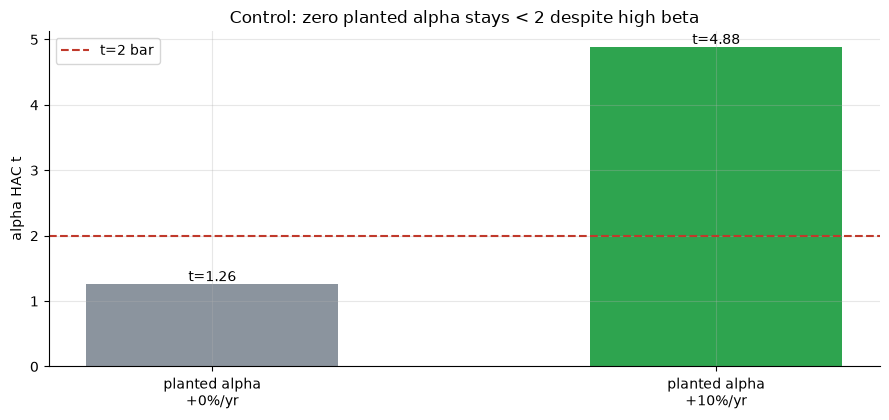

planted +0%/yr: raw excess 3.8%/yr, alpha 3.5%/yr, beta 1.03, HAC t 1.26
planted +10%/yr: raw excess 13.9%/yr, alpha 13.6%/yr, beta 1.03, HAC t 4.88


In [5]:
res=[]
for a in (0.0, 0.0004):
    syn=data.synthetic_reshoring(alpha_daily=a,seed=396); s=st.summarize(syn,'mkt')
    res.append((a*252*100, s['excess_ann']*100, s['alpha_ann']*100, s['beta'], s['t_alpha_hac']))
fig,ax=plt.subplots(figsize=(9.0,4.3))
labels=[f'planted alpha\n{r[0]:+.0f}%/yr' for r in res]; tv=[r[4] for r in res]
ax.bar(labels,tv,color=[GREY,GREEN],width=.5); ax.axhline(2,ls='--',c=RED,label='t=2 bar')
for i,t in enumerate(tv): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('alpha HAC t'); ax.set_title('Control: zero planted alpha stays < 2 despite high beta'); ax.legend()
plt.tight_layout(); plt.show()
for a,e,al,b,t in res: print(f'planted {a:+.0f}%/yr: raw excess {e:.1f}%/yr, alpha {al:.1f}%/yr, beta {b:.2f}, HAC t {t:.2f}')

> 💡 In plain words: with **no** planted alpha the control sits at **HAC *t* = 1.26** (< 2 — no false positive) even though the *raw* excess is +3.8%/yr of pure beta; a **+10%/yr** planted alpha reaches **t = 4.88**. The engine is honest, and the real-tape alpha *t* of ~1.9 (SPY) / 1.0 (ACWI) is exactly what a *tiny-or-absent* edge looks like under a faithful test. The beta is real; the reshoring alpha isn't.

## 5 · The verdict

- **Signal `WEAK`** — raw excess vs SPY clears HAC (*t* = 2.07), but the **CAPM alpha** is **+4.6%/yr at HAC *t* = 1.93** (< 2) and **+2.5%/yr, *t* = 1.01** vs ACWI. Beta-driven, benchmark- and sub-period-dependent, single-name ⇒ WEAK, not REAL (the t≥2 bar on the alpha is not met).
- **Tradability `MIRAGE`** — what survives costs is **β ≈ 1.04 beta** you can buy directly; the alpha is insignificant full-sample and **negative** post-2018, where the benchmark out-Sharpes the basket (0.71 vs 0.54). No NAV-scale edge.
- **Structural edge? `BUSTED`** — alpha **+7.2%/yr pre-2018** vs **-1.0%/yr post-2018** (sign flip at the narrative onset), carried by **one name** (ROK, *t* = 2.16); XLI/EWW insignificant. The thesis fails exactly where it claims to work.

## 6 · Could you trade it? — alpha you can't bank

The operational truth: separate what you're *paid for* (beta — cheap, replicable with an index or a leveraged ETF) from what you'd pay a thematic premium for (alpha). Here is the basket's return split into its beta contribution and its alpha contribution, full sample and post-2018.

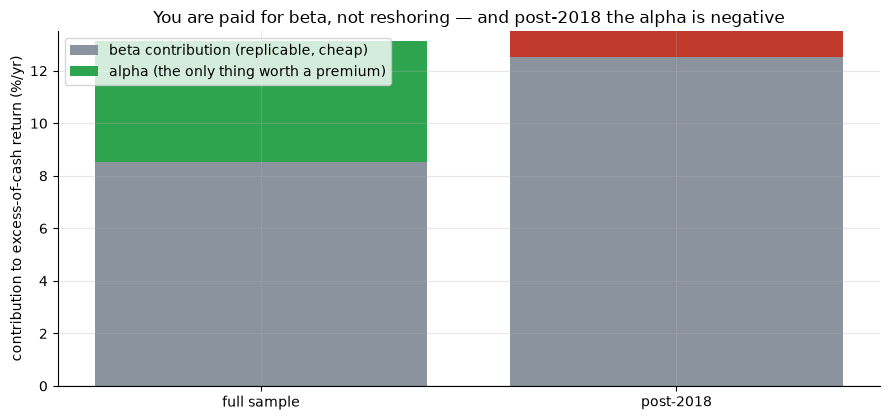

full: beta~8.5%/yr, alpha~4.6%/yr | post-2018: beta~13.5%/yr, alpha~-1.0%/yr


In [6]:
if HAVE_REAL:
    split=data.narrative_start()
    def parts(sub):
        s=st.summarize(sub,'mkt'); rf=st.RF_DAILY*252
        bench_ann=sub['mkt'].mean()*252
        beta_contrib=s['beta']*(bench_ann-rf); alpha_contrib=s['alpha_ann']
        return beta_contrib*100, alpha_contrib*100
    full=parts(F); post=parts(F[F.index>=split])
else:
    full=(8.0, R['spy'][3]); post=(9.0, R['post'][2])
x=np.arange(2); labels=['full sample','post-2018']
betas=[full[0],post[0]]; alphas=[full[1],post[1]]
fig,ax=plt.subplots(figsize=(9.0,4.3))
ax.bar(x,betas,color=GREY,label='beta contribution (replicable, cheap)')
ax.bar(x,alphas,bottom=[max(0,b) for b in betas],color=[GREEN if a>=0 else RED for a in alphas],label='alpha (the only thing worth a premium)')
ax.axhline(0,c='k',lw=.8); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('contribution to excess-of-cash return (%/yr)')
ax.set_title('You are paid for beta, not reshoring — and post-2018 the alpha is negative'); ax.legend()
plt.tight_layout(); plt.show()
print(f'full: beta~{full[0]:.1f}%/yr, alpha~{full[1]:.1f}%/yr | post-2018: beta~{post[0]:.1f}%/yr, alpha~{post[1]:.1f}%/yr')

> 💡 In plain words: the grey (beta) is most of the return and you can buy it for a few basis points as a plain index — no reshoring thesis required. The green/red (alpha) is small and insignificant full-sample and **negative** in the era you'd actually deploy the narrative. There is no sizing, threshold, or cost regime that turns a benchmark-explained, single-name, pre-narrative return into a deployable structural edge. **The story you're paying for is the part the data won't sell you.**

## 7 · Going further

- **The family.** [Study 394 — Defense-Basket](../394-defense-basket/) (war-stocks event study), [Study 393 — AI-Datacenter-Basket](../393-ai-datacenter-basket/) and [Study 356 — GLP-1-Basket](../356-glp1-basket/): the same beta-vs-alpha autopsy on other hot theme baskets.
- **De-name the automation sleeve.** Replace ROK with a diversified robotics ETF (ROBO/BOTZ) or the live reshoring ETF (RSHO) on its short window; the single-name alpha washes out.
- **Beta-matched benchmark.** Race the basket against a β-matched or industrials-only benchmark (not just SPY/ACWI) to kill the residual US/cyclical tilt; a Fama-French / sector-factor attribution would localise what little is left.

*The reproducible core is offline and deterministic; the basket is an explicit proxy with single-name survivorship. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*